# Day 21 — Sprint Review & Model Selection

## ABTalks 60-Day Data Science Challenge

### Objective
Compare the classification models developed during the sprint, analyze their strengths and weaknesses, and select the best Machine Learning system for the fraud detection problem.

### Models Compared
- Random Forest
- XGBoost

### Evaluation Criteria
- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

### Engineering Goal
Select the model that provides the best balance between predictive performance, reliability, interpretability, and business impact.

## 1. Load Previous Model Evaluation Results

The models were evaluated during Day 20 using multiple classification metrics.

In this sprint review, we reuse the saved evaluation results to compare the models systematically.

In [1]:
import pandas as pd

# Load Day 20 evaluation results
metrics = pd.read_csv("day20_metrics_comparison.csv")

# Display the comparison
metrics

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Random Forest,0.9250,0.902778,0.890411,0.896552,0.912927
1,XGBoost,0.9175,0.884354,0.890411,0.887372,0.913062


## 2. Metric-by-Metric Model Comparison

Different evaluation metrics measure different aspects of model performance.

We compare the models across all metrics to identify their individual strengths.

In [2]:
# Metrics where higher values indicate better performance
evaluation_metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1_Score",
    "ROC_AUC"
]

# Find the best model for each metric
winners = {}

for metric in evaluation_metrics:
    best_index = metrics[metric].idxmax()
    winners[metric] = {
        "Best Model": metrics.loc[best_index, "Model"],
        "Score": metrics.loc[best_index, metric]
    }

winners_df = pd.DataFrame(winners).T

winners_df


,Best Model,Score
Accuracy,Random Forest,0.925
Precision,Random Forest,0.902778
Recall,Random Forest,0.890411
F1_Score,Random Forest,0.896552
ROC_AUC,XGBoost,0.913062


## 3. Metric Winners and Ties

A model should not be declared the winner when another model has the same score.

Therefore, ties are explicitly identified before making the final model-selection decision.

In [3]:
# Identify all models that achieve the best score for each metric
metric_winners = []

for metric in evaluation_metrics:
    best_score = metrics[metric].max()
    best_models = metrics.loc[metrics[metric] == best_score, "Model"].tolist()

    metric_winners.append({
        "Metric": metric,
        "Best Score": best_score,
        "Best Model(s)": ", ".join(best_models)
    })

metric_winners_df = pd.DataFrame(metric_winners)

metric_winners_df


,Metric,Best Score,Best Model(s)
0,Accuracy,0.925000,Random Forest
1,Precision,0.902778,Random Forest
2,Recall,0.890411,"Random Forest, XGBoost"
3,F1_Score,0.896552,Random Forest
4,ROC_AUC,0.913062,XGBoost


## 4. Model Strengths and Weaknesses

### Random Forest

**Strengths**
- Highest accuracy at 92.50%.
- Highest precision at 90.28%.
- Highest F1-score at 89.66%.
- Same recall as XGBoost at 89.04%.
- Produces fewer false positives than XGBoost.

**Weaknesses**
- ROC-AUC is slightly lower than XGBoost.
- As an ensemble of decision trees, the model can be less compact and less straightforward to interpret than a single decision tree.

### XGBoost

**Strengths**
- Slightly higher ROC-AUC at 91.31%.
- Same recall as Random Forest.
- Powerful boosting-based approach that can model complex relationships.

**Weaknesses**
- Lower accuracy than Random Forest.
- Lower precision and F1-score.
- Produces slightly more false positives in this experiment.
- The ROC-AUC advantage over Random Forest is extremely small.

### Overall Comparison

Random Forest performs better on most evaluation metrics, while XGBoost has only a marginal advantage in ROC-AUC.

## 5. Business Requirements for Fraud Detection

For this fraud detection system, the primary objective is to identify fraudulent transactions while keeping false alarms under control.

### Metric Priorities

1. Recall — High priority because missed fraud can cause financial loss.
2. Precision — High priority because false fraud alerts can increase investigation costs.
3. F1-Score — Important for balancing precision and recall.
4. ROC-AUC — Useful for measuring overall classification discrimination.
5. Accuracy — Supporting metric for overall correctness.

### Decision Principle

The final model should provide a strong balance between fraud detection,
false-alarm control, and overall predictive performance.

In [4]:
# Calculate Random Forest advantage over XGBoost
rf = metrics[metrics["Model"] == "Random Forest"].iloc[0]
xgb = metrics[metrics["Model"] == "XGBoost"].iloc[0]

comparison = pd.DataFrame({
    "Metric": evaluation_metrics,
    "Random Forest": [rf[m] for m in evaluation_metrics],
    "XGBoost": [xgb[m] for m in evaluation_metrics]
})

comparison["RF Advantage"] = (
    comparison["Random Forest"] - comparison["XGBoost"]
)

comparison

,Metric,Random Forest,XGBoost,RF Advantage
0,Accuracy,0.925000,0.917500,0.007500
1,Precision,0.902778,0.884354,0.018424
2,Recall,0.890411,0.890411,0.000000
3,F1_Score,0.896552,0.887372,0.009180
4,ROC_AUC,0.912927,0.913062,-0.000135


## 6. Final Model Selection

### Selected Model: Random Forest 🌲

Random Forest is selected as the final model for this fraud detection problem.

### Evidence

- Accuracy: 92.50%
- Precision: 90.28%
- Recall: 89.04%
- F1-Score: 89.66%
- ROC-AUC: 91.29%

Random Forest achieves the highest Accuracy, Precision, and F1-Score while matching XGBoost on Recall.

Although XGBoost has a slightly higher ROC-AUC of 91.31%, the difference is only 0.000135.

Random Forest also produces fewer false positives:
- Random Forest: 14 false positives
- XGBoost: 17 false positives

### Engineering Decision

Random Forest provides the better overall balance between fraud detection,
precision, F1-score, and false-alarm control for this particular business problem.

Therefore, Random Forest is selected as the preferred system.

### Important Limitation

This decision is based on the current synthetic dataset and evaluation results.
For production deployment, the model should be validated using real-world data,
cross-validation, monitoring, cost analysis, and additional business requirements.

In [5]:
decision_summary = pd.DataFrame({
    "Decision Factor": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "False Positives",
        "Overall Selection"
    ],
    "Random Forest": [
        "92.50%",
        "90.28%",
        "89.04%",
        "89.66%",
        "91.29%",
        "14",
        "SELECTED"
    ],
    "XGBoost": [
        "91.75%",
        "88.44%",
        "89.04%",
        "88.74%",
        "91.31%",
        "17",
        "Alternative"
    ]
})

decision_summary

,Decision Factor,Random Forest,XGBoost
0,Accuracy,92.50%,91.75%
1,Precision,90.28%,88.44%
2,Recall,89.04%,89.04%
3,F1-Score,89.66%,88.74%
4,ROC-AUC,91.29%,91.31%
5,False Positives,14,17
6,Overall Selection,SELECTED,Alternative


## Final Model Selection

Random Forest is selected as the preferred model because it achieves higher Accuracy,
Precision, and F1-Score while matching XGBoost on Recall.

XGBoost has a slightly higher ROC-AUC, but the difference is negligible.

## Model Performance Comparison

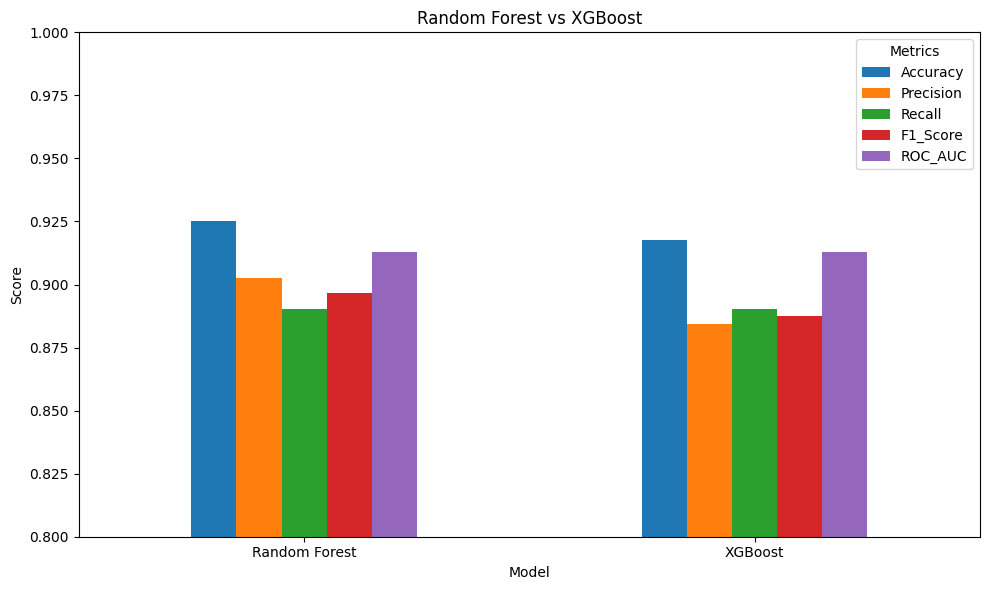

In [6]:
import matplotlib.pyplot as plt

metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1_Score", "ROC_AUC"]

comparison_plot = metrics.set_index("Model")[metrics_to_plot]

comparison_plot.plot(kind="bar", figsize=(10, 6))

plt.title("Random Forest vs XGBoost")
plt.ylabel("Score")
plt.ylim(0.8, 1.0)
plt.xticks(rotation=0)
plt.legend(title="Metrics")
plt.tight_layout()
plt.show()

In [7]:
# Save final comparison table
metrics.to_csv("day21_final_model_comparison.csv", index=False)

print("Saved: day21_final_model_comparison.csv")

Saved: day21_final_model_comparison.csv


## Week 3 Engineering Reflection

This week I learned that building a Machine Learning model is only one part of the process.

I compared Random Forest and XGBoost using multiple evaluation metrics and selected Random Forest based on the overall evidence.

The biggest learning was that model selection depends on the business problem, not just accuracy.

I also learned to consider precision, recall, F1-score, ROC-AUC, false positives, interpretability, and business impact when making ML decisions.

In [8]:
print("Week 3 Complete!")
print("Selected Model: Random Forest")
print("Reason: Best overall balance of performance and business requirements.")

Week 3 Complete!
Selected Model: Random Forest
Reason: Best overall balance of performance and business requirements.
